# Diagnostico del proceso de admision UNAM 2026-2027/1
## Analisis de Inteligencia de Negocios (BI) sobre microdatos reales

**Pregunta rectora:** que nos dicen los datos sobre el proceso de admision y que
decisiones y acciones podriamos proponer a partir de ellos.

**Proposito:** aplicar los principios de BI para transformar datos en informacion
util, conocimiento y propuestas de decision y accion. Este notebook cubre las dos
primeras capas: DATOS e INFORMACION.

A diferencia de un resumen, aqui los hallazgos **se calculan** a partir de bases de
datos publicas a nivel de aspirante. No hay porcentajes escritos a mano en la capa
de INFORMACION: cada cifra sale de una celda que se puede reejecutar.

---
### Procedencia de los datos y honestidad metodologica

Se usan tres bases publicas:

1. **Examen en linea 2021-2026** (una fila por folio): dataset abierto de Castrillo
   Cruz (agn3si), `aciertos_unam_2021_2026.csv`, licencia CC BY 4.0.
2. **Examen de control presencial 2026** (una fila por aspirante, con
   `numero_comprobante`): `resultados_control_2026.csv` del pipeline de Toral
   (jmtoral).
3. **Metadata por oferta-anio** (oferta, aspirantes): `metadata_carreras.csv` del
   mismo pipeline, para construir la demanda historica (aspirantes por lugar).

**Advertencia de cobertura, dicha sin adornos:** el dataset en linea publico
(agn3si) contiene ~167 mil folios para 2026, menos que los 191,306 registrados
oficiales (el archivo completo del equipo original no se publica por su peso). Por
eso el pareo persona-a-persona cubre ~83% de los sustentantes del control, no el
99.6% del material del equipo. Las cifras que salen aqui difieren en decimas de las
del deck, pero **reproducen el mismo diagnostico con una extraccion independiente**:
esa concordancia es, en si misma, evidencia de robustez, no una debilidad que se
esconde.

Los conteos institucionales del embudo (registrados, convocados, acreditados) se
toman como cifras oficiales publicadas: no son plenamente derivables de estas tres
bases y se citan como dato dado del caso.


## 0. Adquisicion de datos y configuracion

In [1]:
import os, urllib.request
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Paleta institucional (tema_unam_bi.json)
AZUL, ORO, AZUL2, ROJO, GRIS, AZULC = "#14213D","#C8901B","#2B3A67","#9B2226","#5A6272","#8FA1C7"
plt.rcParams.update({"figure.dpi":110, "font.size":10, "axes.edgecolor":"#DDE0E6",
                     "axes.grid":True, "grid.color":"#EDEFF3", "grid.linewidth":0.8,
                     "axes.axisbelow":True})
def pct(x, nd=1): return f"{100*x:.{nd}f}%"

DATA = Path("data")
DATA.mkdir(exist_ok=True)
FUENTES = {
 "aciertos.csv": "https://raw.githubusercontent.com/agn3si/ResultadosUNAM---data/main/data/processed/aciertos_unam_2021_2026.csv",
 "control.csv":  "https://raw.githubusercontent.com/jmtoral/admisiones_unam/main/data/consolidated/resultados_control_2026.csv",
 "metadata.csv": "https://raw.githubusercontent.com/jmtoral/admisiones_unam/main/data/consolidated/metadata_carreras.csv",
}
# Si ya tienes los CSV localmente, copialos a ./data/ con estos nombres y no se descargan.
for nombre, url in FUENTES.items():
    dest = DATA / nombre
    if dest.exists() and dest.stat().st_size > 0:
        print(f"[local] {nombre} ({dest.stat().st_size/1e6:.1f} MB)")
    else:
        print(f"[descargando] {nombre} ...")
        urllib.request.urlretrieve(url, dest)
        print(f"           listo ({dest.stat().st_size/1e6:.1f} MB)")


[local] aciertos.csv (60.9 MB)
[local] control.csv (5.8 MB)
[local] metadata.csv (0.1 MB)


In [2]:
import unicodedata, re
def norm(s):
    "Normaliza carrera/campus: sin acentos, mayusculas, espacios colapsados (para unir fuentes)."
    if pd.isna(s): return ""
    s = unicodedata.normalize("NFKD", str(s)).encode("ascii","ignore").decode()
    return re.sub(r"\s+", " ", s).strip().upper()

# En linea 2021-2026 (agn3si)
enlinea = pd.read_csv(DATA/"aciertos.csv", dtype=str, keep_default_na=False)
enlinea["aciertos"] = pd.to_numeric(enlinea["aciertos"], errors="coerce")
enlinea["anio"] = enlinea["año"].astype(int)

# Control 2026 (jmtoral)
control = pd.read_csv(DATA/"control.csv", dtype=str, keep_default_na=False)
control["aciertos"] = pd.to_numeric(control["aciertos"], errors="coerce")

# Metadata por oferta-anio (jmtoral)
meta = pd.read_csv(DATA/"metadata.csv", dtype=str, keep_default_na=False)
for c in ["oferta","aspirantes","presentaron_examen","aciertos_minimos","seleccionados"]:
    meta[c] = pd.to_numeric(meta[c], errors="coerce")

print("en linea :", f"{len(enlinea):,} filas", "| anios:", sorted(enlinea['anio'].unique()))
print("control  :", f"{len(control):,} filas", "| con aciertos:", f"{control['aciertos'].notna().sum():,}")
print("metadata :", f"{len(meta):,} filas (oferta-campus-anio)")


en linea : 1,027,716 filas | anios: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
control  : 59,217 filas | con aciertos: 36,875
metadata : 1,253 filas (oferta-campus-anio)


---
# 1. DATOS

## 1.1 Conteos oficiales del proceso e indicadores

Los siete conteos del proceso (cifras oficiales DGAE-UNAM y Comision Tecnica 2026).

**Antes de cualquier porcentaje, dos reglas de denominador:**
- Las etapas NO son un embudo secuencial: los 58,783 convocados al control no son
  subconjunto de los 21,962 aceptados en linea.
- Los 20,923 acreditados finales SUSTITUYEN a los 21,962 de julio (examen en linea
  anulado): no se suman.


In [3]:
oficial = {
    "registrados":        191306,
    "presentaron_examen": 158712,
    "aceptados_1a":        21962,   # en linea (anulado)
    "cancelados_aprox":     3174,
    "convocados_control":  58783,
    "sustentaron_control": 36875,
    "acreditados_finales": 20923,   # sustituye a aceptados_1a
}
etapas = pd.DataFrame({
    "etapa": ["Registrados","Presentaron examen","Aceptados 1a instancia",
              "Convocados a control","Sustentaron control","Acreditados finales"],
    "valor": [oficial["registrados"],oficial["presentaron_examen"],oficial["aceptados_1a"],
              oficial["convocados_control"],oficial["sustentaron_control"],oficial["acreditados_finales"]],
})
etapas


,etapa,valor
0,Registrados,191306
1,Presentaron examen,158712
2,Aceptados 1a instancia,21962
3,Convocados a control,58783
4,Sustentaron control,36875
5,Acreditados finales,20923


In [4]:
ind = pd.DataFrame([
    ("Participacion",           oficial["presentaron_examen"], oficial["registrados"],        "Presentaron / Registrados"),
    ("Aceptacion inicial",      oficial["aceptados_1a"],       oficial["presentaron_examen"], "Aceptados 1a / Presentaron"),
    ("Cancelacion (aprox)",     oficial["cancelados_aprox"],   oficial["presentaron_examen"], "Cancelados / Presentaron"),
    ("Presentacion al control", oficial["sustentaron_control"],oficial["convocados_control"], "Sustentaron control / Convocados"),
    ("Acreditacion en control", oficial["acreditados_finales"],oficial["sustentaron_control"],"Acreditados / Sustentaron control"),
    ("Admision final",          oficial["acreditados_finales"],oficial["registrados"],        "Acreditados / Registrados"),
], columns=["indicador","numerador","denominador","definicion"])
ind["tasa_%"] = (100*ind["numerador"]/ind["denominador"]).round(2)
ind[["indicador","definicion","numerador","denominador","tasa_%"]]


,indicador,definicion,numerador,denominador,tasa_%
0,Participacion,Presentaron / Registrados,158712,191306,82.96
1,Aceptacion inicial,Aceptados 1a / Presentaron,21962,158712,13.84
2,Cancelacion (aprox),Cancelados / Presentaron,3174,158712,2.00
3,Presentacion al control,Sustentaron control / Convocados,36875,58783,62.73
4,Acreditacion en control,Acreditados / Sustentaron control,20923,36875,56.74
5,Admision final,Acreditados / Registrados,20923,191306,10.94


**Lectura:** la participacion supera el 80%, pero la admision final sobre
registrados es de apenas ~11%. Ese es el numero que un directivo debe tener
presente, no la aceptacion aparente contra bases mas chicas.

## 1.2 Validacion cruzada con la microdata

Dos comprobaciones de que los conteos oficiales son consistentes con las bases:
la cifra que nunca existio (42,885) y el numero de sustentantes del control, que
recalculamos desde `control.csv`.

In [5]:
suma_inexistente = oficial["aceptados_1a"] + oficial["acreditados_finales"]
print(f"Suma incorrecta (21,962 + 20,923): {suma_inexistente:,}  <- cifra que nunca existio")
print(f"Admitidos reales (solo control):   {oficial['acreditados_finales']:,}")
print(f"Sobreconteo:                       {suma_inexistente - oficial['acreditados_finales']:,}")
print()
sustentantes_micro = int(control["aciertos"].notna().sum())
print(f"Sustentaron control segun control.csv: {sustentantes_micro:,}")
print(f"Cifra oficial del deck:                {oficial['sustentaron_control']:,}")
print("Coinciden:" , sustentantes_micro == oficial["sustentaron_control"])


Suma incorrecta (21,962 + 20,923): 42,885  <- cifra que nunca existio
Admitidos reales (solo control):   20,923
Sobreconteo:                       21,962

Sustentaron control segun control.csv: 36,875
Cifra oficial del deck:                36,875
Coinciden: True


## 1.3 Visualizacion 1 - El embudo con denominador visible

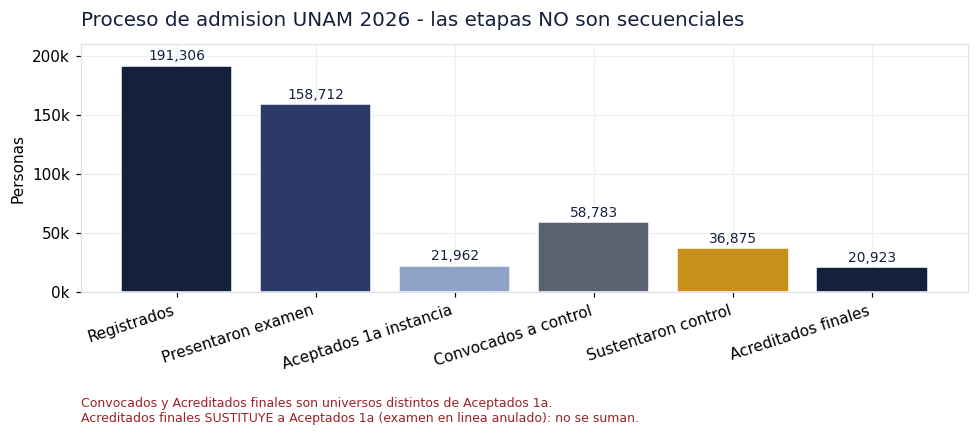

In [6]:
fig, ax = plt.subplots(figsize=(9,4.6))
col = [AZUL,AZUL2,AZULC,GRIS,ORO,AZUL]
b = ax.bar(etapas["etapa"], etapas["valor"], color=col, edgecolor="white")
for r,v in zip(b, etapas["valor"]):
    ax.text(r.get_x()+r.get_width()/2, v+2500, f"{v:,}", ha="center", va="bottom", fontsize=9, color=AZUL)
ax.set_title("Proceso de admision UNAM 2026 - las etapas NO son secuenciales",
             color=AZUL, fontsize=13, loc="left", pad=12)
ax.set_ylabel("Personas"); ax.set_ylim(0,210000)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x,_:f"{x/1000:.0f}k"))
plt.xticks(rotation=18, ha="right")
ax.text(0.0,-0.42,
        "Convocados y Acreditados finales son universos distintos de Aceptados 1a.\n"
        "Acreditados finales SUSTITUYE a Aceptados 1a (examen en linea anulado): no se suman.",
        transform=ax.transAxes, fontsize=8.2, color=ROJO, va="top")
plt.tight_layout(); plt.show()


## 1.4 Panel visual de KPI (cada tasa con su denominador)

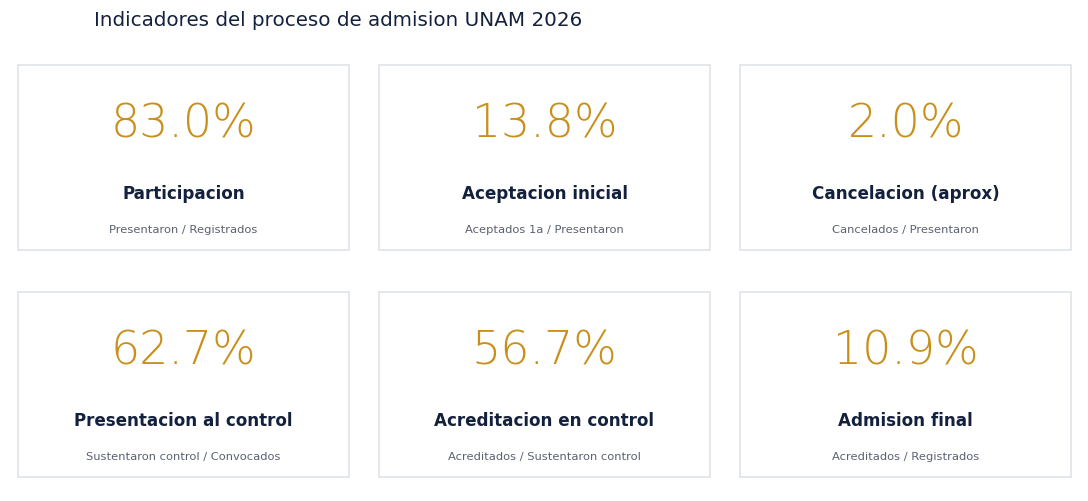

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(10, 4.6))
tarjetas = list(zip(ind["indicador"], ind["tasa_%"], ind["definicion"]))
for ax, (nom, val, den) in zip(axes.ravel(), tarjetas):
    ax.axis("off")
    ax.add_patch(plt.Rectangle((0.02,0.06),0.96,0.88, transform=ax.transAxes,
                 facecolor="white", edgecolor="#DDE0E6"))
    ax.text(0.5,0.66,f"{val:.1f}%", ha="center", va="center", fontsize=30, color=ORO, weight="light")
    ax.text(0.5,0.33,nom, ha="center", va="center", fontsize=11, color=AZUL, weight="bold")
    ax.text(0.5,0.16,den, ha="center", va="center", fontsize=7.5, color=GRIS)
fig.suptitle("Indicadores del proceso de admision UNAM 2026", color=AZUL, fontsize=13, x=0.09, ha="left")
plt.tight_layout(); plt.show()


---
# 2. INFORMACION

Cada hallazgo separa: lo que los datos **DEMUESTRAN**, lo que puede
**INTERPRETARSE**, lo que es **HIPOTESIS**, y donde falta, el **DATO FALTANTE**.
Todas las cifras de esta seccion se computan en las celdas.


## Hallazgo 1 - La distribucion de aciertos se rompio en 2026

Se calcula, por anio, la proporcion de sustentantes del examen en linea con 100 o
mas aciertos (de 120). Datos: agn3si 2021-2026.

In [8]:
pres = enlinea[enlinea["aciertos"].notna()]
h1 = (pres.groupby("anio")["aciertos"]
        .agg(sustentantes="count",
             prop_ge100=lambda s:(s>=100).mean(),
             prop_ge110=lambda s:(s>=110).mean())
        .reset_index())
h1["%_ge100"] = (100*h1["prop_ge100"]).round(1)
h1["%_ge110"] = (100*h1["prop_ge110"]).round(1)
prom_hist = pres.loc[pres.anio!=2026,"aciertos"].ge(100).mean()
val_2026  = pres.loc[pres.anio==2026,"aciertos"].ge(100).mean()
print(f">=100 aciertos: promedio 2021-2025 = {pct(prom_hist)}  ->  2026 = {pct(val_2026)}")
print(f"multiplicador: x{val_2026/prom_hist:.1f}")
h1[["anio","sustentantes","%_ge100","%_ge110"]]


>=100 aciertos: promedio 2021-2025 = 3.1%  ->  2026 = 17.0%
multiplicador: x5.5


,anio,sustentantes,%_ge100,%_ge110
0,2021,140446,2.9,0.7
1,2022,153592,2.6,0.5
2,2023,152860,2.8,0.6
3,2024,139285,3.5,0.8
4,2025,149433,3.7,1.0
5,2026,138406,17.0,5.8


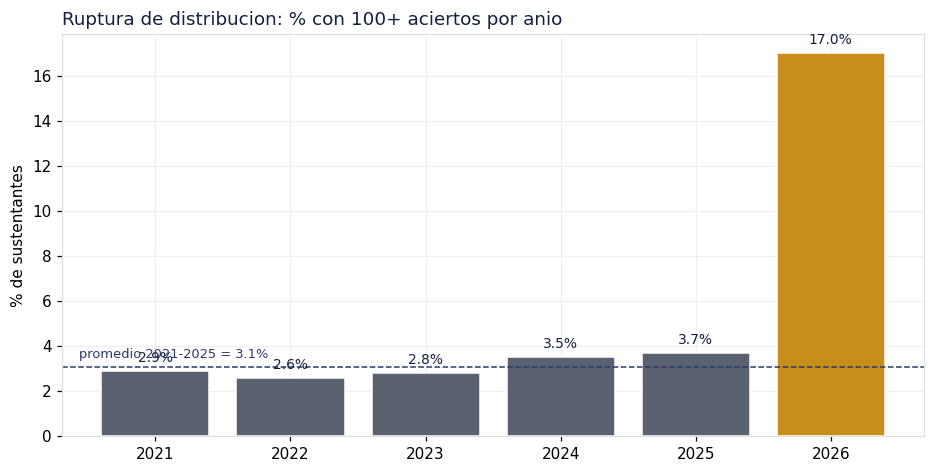

In [9]:
fig, ax = plt.subplots(figsize=(8.6,4.4))
cols = [GRIS]*5 + [ORO]
ax.bar(h1["anio"].astype(str), h1["%_ge100"], color=cols, edgecolor="white")
for x,v in zip(h1["anio"].astype(str), h1["%_ge100"]):
    ax.text(x, v+0.4, f"{v:.1f}%", ha="center", fontsize=9, color=AZUL)
ax.axhline(100*prom_hist, ls="--", lw=1, color=AZUL2)
ax.text(0.02, 100*prom_hist+0.4, f"promedio 2021-2025 = {pct(prom_hist)}",
        transform=ax.get_yaxis_transform(), fontsize=8.5, color=AZUL2)
ax.set_title("Ruptura de distribucion: % con 100+ aciertos por anio",
             color=AZUL, fontsize=12, loc="left")
ax.set_ylabel("% de sustentantes")
plt.tight_layout(); plt.show()


**Grafica de apoyo A - el desplazamiento completo de la distribucion.** No es
solo la cola: se compara la forma entera de la distribucion de aciertos, historico
(2021-2025) contra 2026.

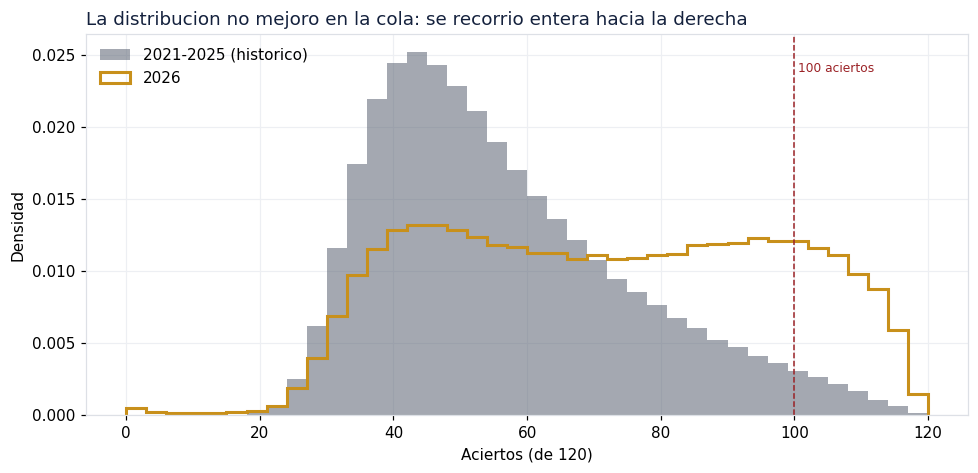

In [10]:
hist_ac = pres.loc[pres.anio!=2026, "aciertos"]
ac_2026 = pres.loc[pres.anio==2026, "aciertos"]
bins = np.arange(0, 121, 3)
fig, ax = plt.subplots(figsize=(9,4.4))
ax.hist(hist_ac, bins=bins, density=True, color=GRIS, alpha=0.55, label="2021-2025 (historico)")
ax.hist(ac_2026, bins=bins, density=True, histtype="step", lw=2, color=ORO, label="2026")
ax.axvline(100, color=ROJO, ls="--", lw=1); ax.text(100.5, ax.get_ylim()[1]*0.9, "100 aciertos", color=ROJO, fontsize=8)
ax.set_title("La distribucion no mejoro en la cola: se recorrio entera hacia la derecha",
             color=AZUL, fontsize=12, loc="left")
ax.set_xlabel("Aciertos (de 120)"); ax.set_ylabel("Densidad")
ax.legend(frameon=False); plt.tight_layout(); plt.show()


**Grafica de apoyo B - abanico de percentiles por anio.** Muestra que en 2026
la distribucion no se comprimio, se ensancho: sube la mediana y sobre todo los
percentiles altos.

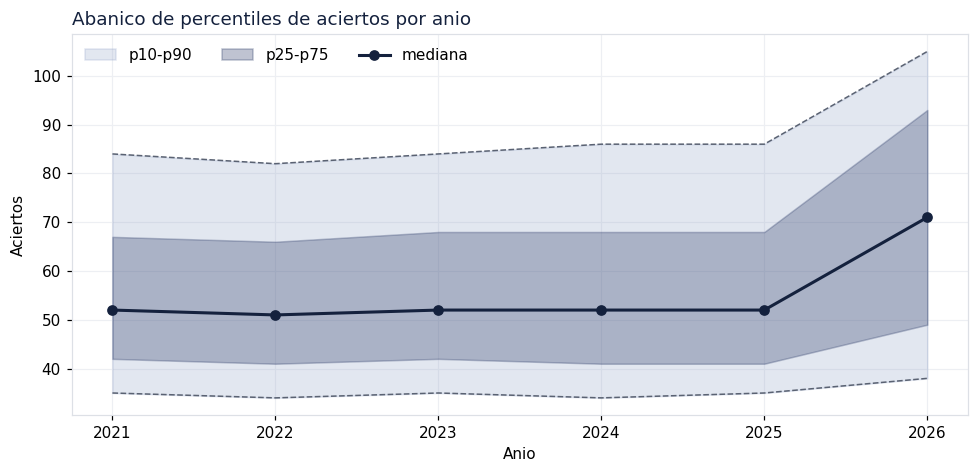

In [11]:
qs = [0.10,0.25,0.50,0.75,0.90]
fan = pres.groupby("anio")["aciertos"].quantile(qs).unstack()
fig, ax = plt.subplots(figsize=(9,4.4))
ax.fill_between(fan.index, fan[0.10], fan[0.90], color=AZULC, alpha=0.25, label="p10-p90")
ax.fill_between(fan.index, fan[0.25], fan[0.75], color=AZUL2, alpha=0.30, label="p25-p75")
ax.plot(fan.index, fan[0.50], color=AZUL, lw=2, marker="o", label="mediana")
for p,c in [(0.90,GRIS),(0.10,GRIS)]:
    ax.plot(fan.index, fan[p], color=c, lw=1, ls="--")
ax.set_title("Abanico de percentiles de aciertos por anio", color=AZUL, fontsize=12, loc="left")
ax.set_xlabel("Anio"); ax.set_ylabel("Aciertos")
ax.legend(frameon=False, ncol=3); plt.tight_layout(); plt.show()


- **DEMUESTRAN:** la proporcion con 100 o mas aciertos se mantiene alrededor
  del 3% durante 2021-2025 y salta a ~17% en 2026 (multiplicador calculado arriba).
- **SE INTERPRETA:** no es mejora gradual por mejor preparacion. Una poblacion de
  ~138 mil sustentantes no desplaza asi su distribucion en un anio; coincide con el
  primer anio de aplicacion en linea.
- **ES HIPOTESIS:** que la causa sea uso de IA o suplantacion. La Comision Tecnica
  no lo concluyo, y este analisis tampoco lo afirma.
- **Gobernanza:** la anomalia se detecto primero desde el publico, con datos
  abiertos de la DGAE; la institucion reacciono despues.


## Hallazgo 2 - La misma persona bajo su puntaje en el control

Se parea a cada persona entre examen en linea 2026 y examen de control por
(carrera, campus, folio/numero de comprobante). No compara grupos: compara a cada
persona consigo misma.

In [12]:
def clave(df, car, cam, fol):
    return df[car].map(norm)+"|"+df[cam].map(norm)+"|"+df[fol].astype(str).str.strip()

el26 = enlinea[enlinea.anio==2026].copy()
el26["k"] = clave(el26, "carrera", "plantel", "folio")
el26 = el26.rename(columns={"aciertos":"aciertos_linea"})[["k","aciertos_linea","carrera","plantel"]]

ctl = control[control["aciertos"].notna()].copy()
ctl["k"] = clave(ctl, "carrera", "campus", "numero_comprobante")
ctl = ctl.rename(columns={"aciertos":"aciertos_control"})
ctl["oferta"] = ctl["carrera"].map(norm)+" | "+ctl["campus"].map(norm)

par = ctl.merge(el26[["k","aciertos_linea"]], on="k", how="inner").dropna(subset=["aciertos_linea"])
par["delta"] = par["aciertos_control"] - par["aciertos_linea"]

cobertura = len(par)/len(ctl)
print(f"Sustentantes del control con aciertos: {len(ctl):,}")
print(f"Pareados a examen en linea 2026:       {len(par):,}  (cobertura {pct(cobertura)})")
print()
print(f"% que BAJO:  {pct((par.delta<0).mean())}")
print(f"% igual:     {pct((par.delta==0).mean())}")
print(f"% que subio: {pct((par.delta>0).mean())}")
print(f"Mediana del cambio individual: {par.delta.median():.0f} aciertos")
ofe = par.groupby("oferta")["delta"].median()
print(f"Ofertas con mediana negativa: {(ofe<0).sum()} de {len(ofe)}")


Sustentantes del control con aciertos: 36,875
Pareados a examen en linea 2026:       30,740  (cobertura 83.4%)

% que BAJO:  96.2%
% igual:     1.5%
% que subio: 2.2%
Mediana del cambio individual: -32 aciertos
Ofertas con mediana negativa: 182 de 184


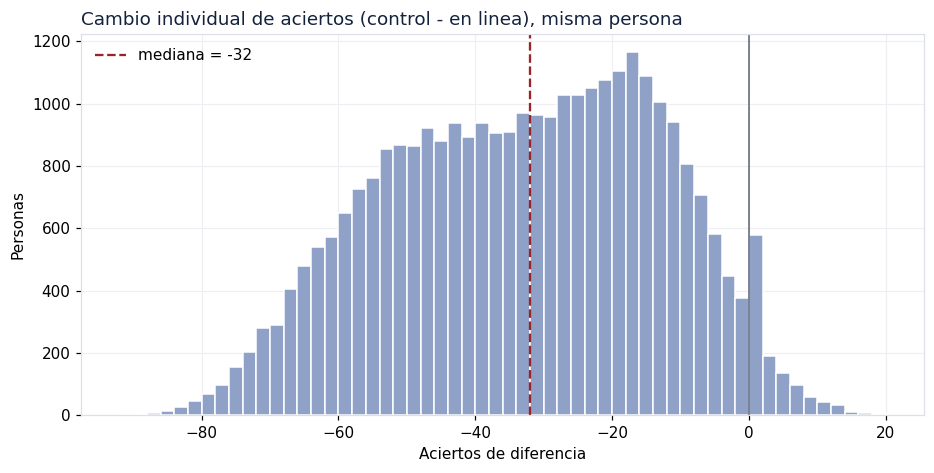

In [13]:
fig, ax = plt.subplots(figsize=(8.6,4.4))
ax.hist(par["delta"], bins=range(int(par.delta.min())-1, int(par.delta.max())+2, 2),
        color=AZULC, edgecolor="white")
ax.axvline(0, color=GRIS, lw=1)
ax.axvline(par.delta.median(), color=ROJO, lw=1.5, ls="--",
           label=f"mediana = {par.delta.median():.0f}")
ax.set_title("Cambio individual de aciertos (control - en linea), misma persona",
             color=AZUL, fontsize=12, loc="left")
ax.set_xlabel("Aciertos de diferencia"); ax.set_ylabel("Personas")
ax.legend(frameon=False); plt.tight_layout(); plt.show()


**Grafica de apoyo C - cada persona como un punto.** Eje X: aciertos en linea;
eje Y: aciertos en control. La diagonal es "no cambio". Casi toda la masa cae por
debajo: la misma persona saco menos en el control.

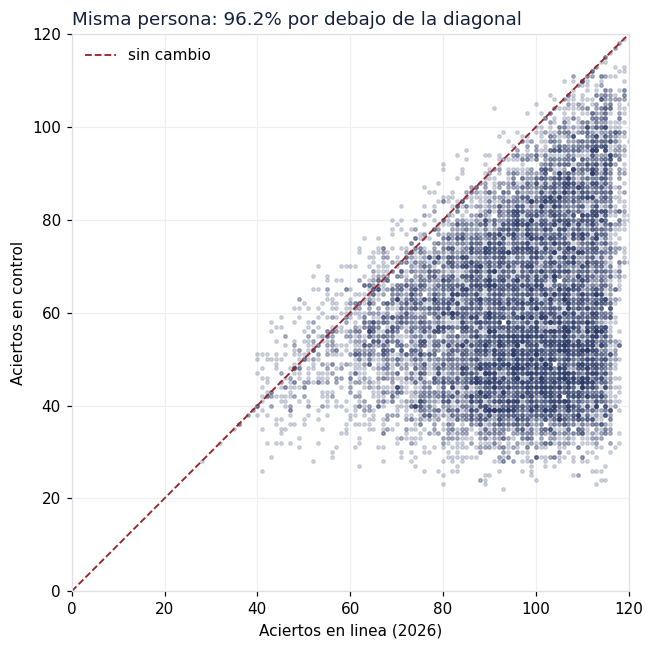

In [14]:
samp = par.sample(min(12000, len(par)), random_state=0)
fig, ax = plt.subplots(figsize=(6.4,6.0))
ax.scatter(samp["aciertos_linea"], samp["aciertos_control"], s=5, alpha=0.18, color=AZUL2)
lim = [0, 120]; ax.plot(lim, lim, color=ROJO, lw=1.2, ls="--", label="sin cambio")
frac_debajo = (par["aciertos_control"] < par["aciertos_linea"]).mean()
ax.set_xlim(lim); ax.set_ylim(lim); ax.set_aspect("equal")
ax.set_xlabel("Aciertos en linea (2026)"); ax.set_ylabel("Aciertos en control")
ax.set_title(f"Misma persona: {pct(frac_debajo)} por debajo de la diagonal",
             color=AZUL, fontsize=12, loc="left")
ax.legend(frameon=False, loc="upper left"); plt.tight_layout(); plt.show()


**Correccion importante: las carreras que 'subieron' en el control no existen.**
Circulo que en Fisica o Aeroespacial el control dio medianas mas altas. Esa
comparacion es POR OFERTA (gente distinta en cada examen). Con las MISMAS personas
pareadas, se recomputa abajo.

In [15]:
def compara(nombre_carrera):
    sub = par[par["carrera"].map(norm).str.contains(norm(nombre_carrera))]
    if sub.empty: return None
    # por oferta = mediana de todos los que presentaron cada examen (gente distinta)
    car_norm = sub["carrera"].map(norm).iloc[0]
    porof_ctrl = ctl.loc[ctl["carrera"].map(norm)==car_norm, "aciertos_control"].median()
    porof_lin  = el26.loc[el26["carrera"].map(norm)==car_norm, "aciertos_linea"].median()
    return {"carrera":nombre_carrera, "n_pareadas":len(sub),
            "por_oferta_control": porof_ctrl, "por_oferta_linea": porof_lin,
            "mismas_linea": sub["aciertos_linea"].median(),
            "mismas_control": sub["aciertos_control"].median(),
            "cambio_mismas": sub["delta"].median()}
tabla = pd.DataFrame([r for c in ["FISICA","AEROESPACIAL","MATEMATICAS APLICADAS","URBANISMO"]
                      if (r:=compara(c))]).round(1)
tabla


,carrera,n_pareadas,por_oferta_control,por_oferta_linea,mismas_linea,mismas_control,cambio_mismas
0,FISICA,156,97.0,85.0,108.0,93.0,-13.0
1,AEROESPACIAL,65,88.0,79.0,113.0,88.0,-21.0
2,MATEMATICAS APLICADAS,286,93.0,88.0,79.0,60.5,-12.0
3,URBANISMO,47,73.0,81.5,97.0,73.0,-21.0


- **DEMUESTRAN:** la gran mayoria de las personas pareadas obtuvo menos
  aciertos en el control; la mediana del cambio individual es negativa; casi todas
  las ofertas tienen mediana negativa (cifras exactas en las celdas).
- **SE INTERPRETA:** la comparacion por oferta que sugeria mejoras mezcla gente
  distinta. Con las mismas personas ninguna de esas carreras sube.
- **ES HIPOTESIS:** atribuir la caida a una conducta individual concreta. El pareo
  mide el cambio, no su causa.
- **Nota de muestra:** al control solo se convoco a quien supero minimos historicos,
  y de ellos acudio ~63%: doble autoseleccion que condiciona quien esta en la muestra.


## Hallazgo 3 (analisis propio) - La caida escala con la competencia

Se cruza la caida individual mediana por oferta contra la demanda historica
(aspirantes por lugar, promedio 2021-2025; 2026 se excluye por estar contaminado).

In [16]:
meta["oferta_k"] = meta["carrera"].map(norm)+" | "+meta["campus"].map(norm)
hist = (meta[meta.year.astype(int).between(2021,2025)]
        .groupby("oferta_k")
        .apply(lambda d: d["aspirantes"].sum()/d["oferta"].sum() if d["oferta"].sum()>0 else np.nan)
        .rename("asp_por_lugar"))

porof = (par.groupby("oferta")
           .agg(caida=("delta","median"), pct_bajo=("delta", lambda x:(x<0).mean()), n=("delta","size"))
           .join(hist, on="oferta").dropna())
porof = porof[porof["n"]>=10]          # ofertas con al menos 10 personas pareadas

x = np.log(porof["asp_por_lugar"]); y = porof["caida"]
r = np.corrcoef(x, y)[0,1]
rs = np.corrcoef(pd.Series(x).rank(), pd.Series(y).rank())[0,1]  # Spearman
pend = np.polyfit(x, y, 1)[0]
print(f"Ofertas: {len(porof)} | personas: {int(porof.n.sum()):,}")
print(f"Pearson(log demanda, caida) r = {r:.2f}")
print(f"Spearman = {rs:.2f}")
print(f"Duplicar la demanda (x2) implica un cambio de {pend*np.log(2):.1f} aciertos en la caida")


Ofertas: 157 | personas: 29,969
Pearson(log demanda, caida) r = -0.78
Spearman = -0.81
Duplicar la demanda (x2) implica un cambio de -5.9 aciertos en la caida


In [17]:
porof = porof.assign(cuartil=pd.qcut(porof["asp_por_lugar"], 4, labels=["Q1 baja","Q2","Q3","Q4 alta"]))
cuart = porof.groupby("cuartil").agg(
    asp_por_lugar=("asp_por_lugar","median"),
    caida_mediana=("caida","median"),
    pct_bajo=("pct_bajo","median")).round(2)
cuart["pct_bajo_%"] = (100*cuart["pct_bajo"]).round(1)
cuart[["asp_por_lugar","caida_mediana","pct_bajo_%"]]


,asp_por_lugar,caida_mediana,pct_bajo_%
cuartil,,,
Q1 baja,1.88,-11.0,86.0
Q2,4.53,-20.0,94.0
Q3,8.81,-29.0,98.0
Q4 alta,24.56,-37.0,98.0


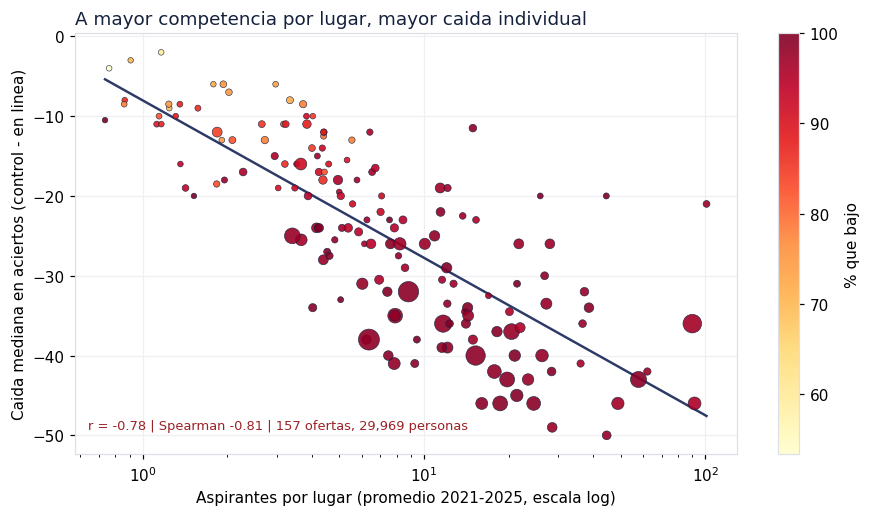

In [18]:
fig, ax = plt.subplots(figsize=(8.4,4.8))
sc = ax.scatter(porof["asp_por_lugar"], porof["caida"],
                s=12+porof["n"]/8, c=100*porof["pct_bajo"], cmap="YlOrRd",
                edgecolor=AZUL, linewidth=0.4, alpha=0.9, zorder=3)
xs = np.linspace(x.min(), x.max(), 50)
ax.plot(np.exp(xs), np.polyval(np.polyfit(x,y,1), xs), color=AZUL2, lw=1.6, zorder=2)
ax.set_xscale("log")
ax.set_xlabel("Aspirantes por lugar (promedio 2021-2025, escala log)")
ax.set_ylabel("Caida mediana en aciertos (control - en linea)")
ax.set_title("A mayor competencia por lugar, mayor caida individual",
             color=AZUL, fontsize=12, loc="left")
cb = plt.colorbar(sc); cb.set_label("% que bajo")
ax.text(0.02,0.06, f"r = {r:.2f} | Spearman {rs:.2f} | {len(porof)} ofertas, {int(porof.n.sum()):,} personas",
        transform=ax.transAxes, fontsize=8.5, color=ROJO)
plt.tight_layout(); plt.show()


**Grafica de apoyo D - el gradiente por cuartil, en barras.** La misma senal
del scatter, en la forma mas directa para un directivo: a mayor competencia, mayor
caida y mayor porcentaje que bajo.

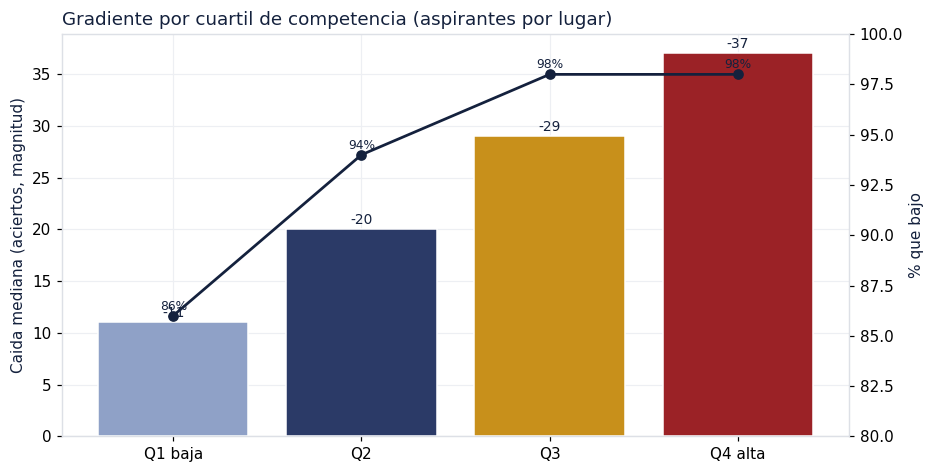

In [19]:
fig, ax1 = plt.subplots(figsize=(8.6,4.4))
xc = np.arange(len(cuart))
b = ax1.bar(xc, -cuart["caida_mediana"], color=[AZULC,AZUL2,ORO,ROJO], edgecolor="white")
for i,v in enumerate(cuart["caida_mediana"]):
    ax1.text(i, -v+0.5, f"{v:.0f}", ha="center", fontsize=9, color=AZUL)
ax1.set_xticks(xc); ax1.set_xticklabels(cuart.index)
ax1.set_ylabel("Caida mediana (aciertos, magnitud)", color=AZUL)
ax2 = ax1.twinx()
ax2.plot(xc, cuart["pct_bajo_%"], color=AZUL, marker="o", lw=1.8)
for i,v in enumerate(cuart["pct_bajo_%"]):
    ax2.text(i, v+0.3, f"{v:.0f}%", ha="center", fontsize=8, color=AZUL)
ax2.set_ylabel("% que bajo", color=AZUL); ax2.set_ylim(80,100); ax2.grid(False)
ax1.set_title("Gradiente por cuartil de competencia (aspirantes por lugar)",
              color=AZUL, fontsize=12, loc="left")
plt.tight_layout(); plt.show()


- **DEMUESTRAN:** correlacion negativa fuerte entre demanda por lugar y caida.
  Del cuartil de menor competencia al de mayor, la caida crece de forma monotona y
  el porcentaje que bajo sube tambien (tabla de cuartiles).
- **SE INTERPRETA:** ninguna explicacion uniforme (cambio de formato, estres,
  fatiga) predice ese gradiente: afectarian igual a toda carrera. Lo unico que varia
  con la competencia es el incentivo.
- **ES HIPOTESIS / LIMITE:** es una asociacion **ecologica** a nivel de oferta. No
  prueba irregularidad de ninguna persona; usarla para senalar carreras o personas
  seria el mismo error que critica el caso.


## Hallazgo 4 - El costo de la reposicion (conteos oficiales)

In [20]:
convocados, sustentaron = oficial["convocados_control"], oficial["sustentaron_control"]
no_acudieron = convocados - sustentaron
lug_anunciados, ingresos = 50113, 49074
sin_asignar = lug_anunciados - ingresos
print(f"Convocados:        {convocados:,}")
print(f"Sustentaron:       {sustentaron:,}  ({pct(sustentaron/convocados)})")
print(f"No acudieron:      {no_acudieron:,}  ({pct(no_acudieron/convocados)})")
print(f"Lugares sin asignar: {sin_asignar:,}  ({pct(sin_asignar/lug_anunciados)} de lo anunciado)")


Convocados:        58,783
Sustentaron:       36,875  (62.7%)
No acudieron:      21,908  (37.3%)
Lugares sin asignar: 1,039  (2.1% de lo anunciado)


**Grafica de apoyo E - la cadena del costo.** Del universo convocado a quienes
sustentaron, y el cupo que quedo sin ocupar.

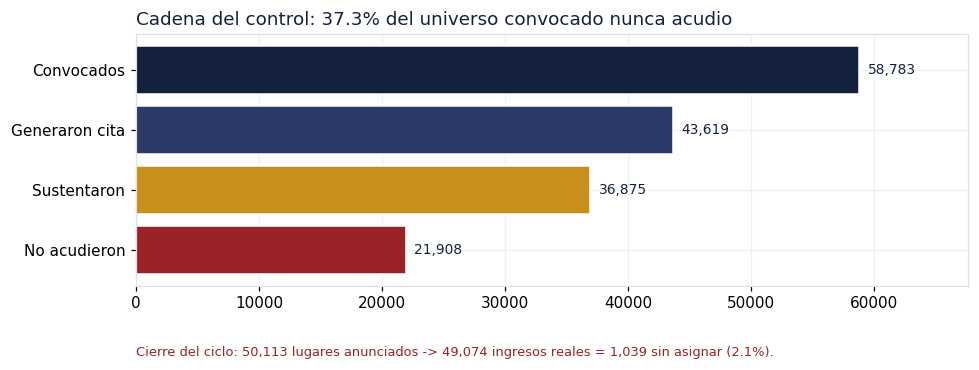

In [21]:
etapas_costo = ["Convocados", "Generaron cita", "Sustentaron", "No acudieron"]
vals_costo   = [convocados, 43619, sustentaron, no_acudieron]
colores_c    = [AZUL, AZUL2, ORO, ROJO]
fig, ax = plt.subplots(figsize=(9,3.6))
b = ax.barh(etapas_costo[::-1], vals_costo[::-1], color=colores_c[::-1], edgecolor="white")
for r,v in zip(b, vals_costo[::-1]):
    ax.text(v+700, r.get_y()+r.get_height()/2, f"{v:,}", va="center", fontsize=9, color=AZUL)
ax.set_xlim(0, convocados*1.15)
ax.set_title(f"Cadena del control: {pct(no_acudieron/convocados)} del universo convocado nunca acudio",
             color=AZUL, fontsize=12, loc="left")
ax.text(0.0, -0.28, f"Cierre del ciclo: {lug_anunciados:,} lugares anunciados -> "
        f"{ingresos:,} ingresos reales = {sin_asignar:,} sin asignar ({pct(sin_asignar/lug_anunciados)}).",
        transform=ax.transAxes, fontsize=8.5, color=ROJO)
plt.tight_layout(); plt.show()


- **DEMUESTRAN:** mas de un tercio del universo convocado no rindio la prueba;
  el ciclo cerro con 1,039 lugares anunciados sin asignar.
- **SE INTERPRETA:** el costo es medible: cupo desaprovechado mas el gasto operativo
  de una segunda aplicacion en cuatro sedes (CDMX, Leon, Oaxaca, Tijuana). Cuidado
  con el denominador: sobre quienes ya tenian cita la asistencia es ~85%; sobre el
  universo convocado es 62.7%.
- **ES HIPOTESIS:** que la ausencia se explique por costo de traslado, inscripcion
  previa en otra institucion o desistimiento. Ninguna esta medida.
- **FALTA EL DATO:** encuesta a no asistentes, distribucion por sede, y costo total
  del Examen de Control.


## Hallazgo 5 - Selectividad por carrera y cancelaciones (columna `acreditado`)

Usando el estatus `acreditado` (S=admitido, N=no admitido, C=cancelado) del examen
en linea se calculan dos cosas que no requieren datos extra: la **tasa de aceptacion
por carrera** (selectividad) y las **cancelaciones por irregularidad por anio** (uno
de los siete datos oficiales del caso).

**Salvedad que no se puede omitir:** para 2026, el estatus S de esta base
corresponde a la ronda en linea que despues fue **anulada**; no es la admision
final (esa salio del control, 20,923). Toda cifra de 2026 aqui va etiquetada como
"en linea (anulado)".

In [22]:
# Tasa de aceptacion global por anio (S / presentaron)
acept_anio = (pres.assign(S=pres["acreditado"].eq("S"))
                  .groupby("anio")["S"].mean().mul(100).round(1)
                  .rename("aceptacion_%").reset_index())
acept_anio["nota"] = np.where(acept_anio["anio"]==2026, "en linea (ANULADO)", "final")
print(acept_anio.to_string(index=False))


 anio  aceptacion_%               nota
 2021           9.6              final
 2022           9.0              final
 2023          10.0              final
 2024          10.1              final
 2025           9.5              final
 2026          12.0 en linea (ANULADO)


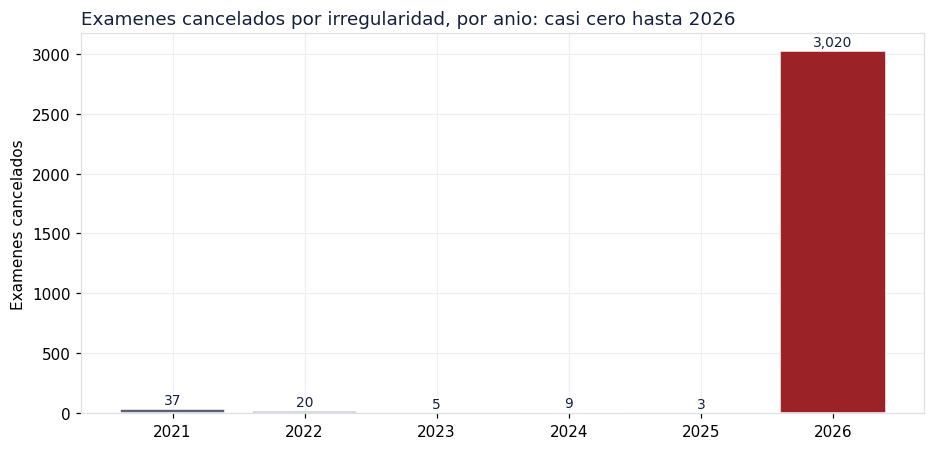

Cancelados 2021-2025 (suma): 74 | 2026: 3020


In [23]:
# Cancelaciones por irregularidad por anio (estatus C)
canc = enlinea.groupby("anio")["acreditado"].apply(lambda s:(s=="C").sum()).rename("cancelados").reset_index()
fig, ax = plt.subplots(figsize=(8.6,4.2))
cols = [GRIS]*5 + [ROJO]
ax.bar(canc["anio"].astype(str), canc["cancelados"], color=cols, edgecolor="white")
for x,v in zip(canc["anio"].astype(str), canc["cancelados"]):
    ax.text(x, v+40, f"{v:,}", ha="center", fontsize=9, color=AZUL)
ax.set_title("Examenes cancelados por irregularidad, por anio: casi cero hasta 2026",
             color=AZUL, fontsize=12, loc="left")
ax.set_ylabel("Examenes cancelados")
plt.tight_layout(); plt.show()
print("Cancelados 2021-2025 (suma):", int(canc[canc.anio!=2026]["cancelados"].sum()),
      "| 2026:", int(canc[canc.anio==2026]["cancelados"].iloc[0]))


In [24]:
# Selectividad por carrera-campus con la serie final 2021-2025 (se excluye 2026 anulado)
hs = pres[pres.anio.between(2021,2025)].copy()
hs["oferta"] = hs["carrera"].map(norm)+" | "+hs["plantel"].map(norm)
sel = (hs.assign(S=hs["acreditado"].eq("S"))
         .groupby("oferta").agg(presentaron=("S","size"), aceptacion=("S","mean")))
sel = sel[sel["presentaron"]>=500]
sel["aceptacion_%"] = (100*sel["aceptacion"]).round(1)
top_sel = sel.sort_values("aceptacion_%").head(12)
print("Aceptacion global 2021-2025:", round(100*hs['acreditado'].eq('S').mean(),1), "%")
print("\n12 ofertas MAS selectivas (menor aceptacion):")
top_sel[["presentaron","aceptacion_%"]]


Aceptacion global 2021-2025: 9.6 %

12 ofertas MAS selectivas (menor aceptacion):


,presentaron,aceptacion_%
oferta,,
MEDICO CIRUJANO | FES ZARAGOZA,20161,1.3
INGENIERIA AEROESPACIAL | FACULTAD DE INGENIERIA,5387,1.4
MEDICO CIRUJANO | FACULTAD DE MEDICINA,65679,1.5
DISENO GRAFICO | FES ACATLAN,9725,1.9
PSICOLOGIA | FACULTAD DE PSICOLOGIA,19594,2.0
MEDICO CIRUJANO | FES IZTACALA,25416,2.1
MEDICINA VETERINARIA Y ZOOTECNIA | FACULTAD DE MEDICINA VETERINARIA Y ZOOTECNIA,17694,2.4
NUTRIOLOGIA | FES ZARAGOZA,8846,2.7
ARTES VISUALES | FACULTAD DE ARTES Y DISENO,9316,3.1


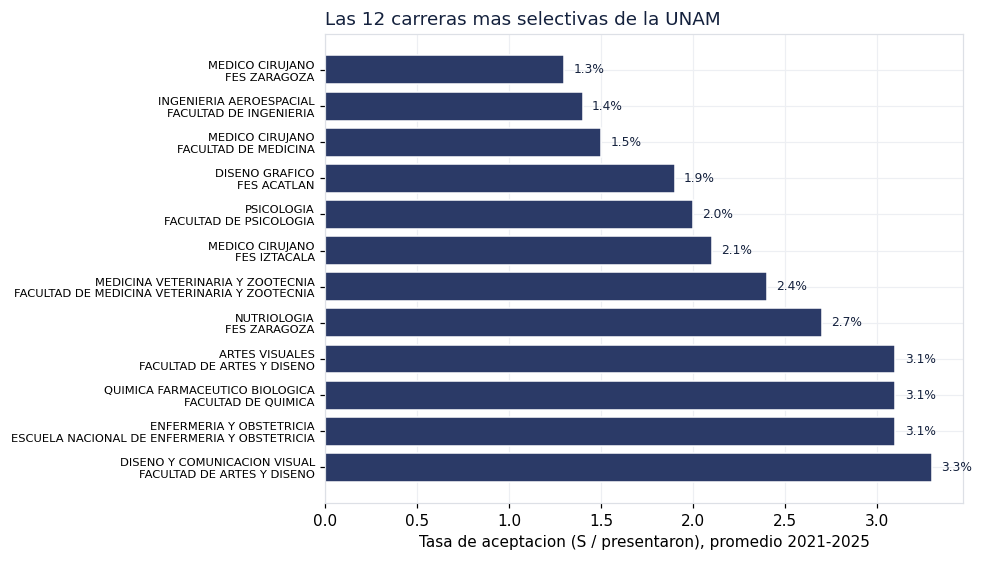

In [25]:
fig, ax = plt.subplots(figsize=(9,5.2))
etq = [o.replace(" | ", "\n") for o in top_sel.index]
ax.barh(range(len(top_sel))[::-1], top_sel["aceptacion_%"], color=AZUL2, edgecolor="white")
ax.set_yticks(range(len(top_sel))[::-1]); ax.set_yticklabels(etq, fontsize=7.5)
for i,v in enumerate(top_sel["aceptacion_%"][::-1]):
    ax.text(v+0.05, i, f"{v:.1f}%", va="center", fontsize=8, color=AZUL)
ax.set_xlabel("Tasa de aceptacion (S / presentaron), promedio 2021-2025")
ax.set_title("Las 12 carreras mas selectivas de la UNAM", color=AZUL, fontsize=12, loc="left")
plt.tight_layout(); plt.show()


- **DEMUESTRAN:** las cancelaciones por irregularidad son practicamente nulas
  entre 2021 y 2025 (decenas por anio) y saltan a ~3 mil en 2026. La aceptacion
  historica global ronda 9-10%, con Medicina e Ingenieria Aeroespacial como las mas
  selectivas (1-2% de aceptacion).
- **SE INTERPRETA:** el salto de cancelaciones acompana a la anomalia de
  distribucion del Hallazgo 1; y las carreras mas selectivas coinciden con las de
  mayor competencia por lugar del Hallazgo 3, donde la caida en el control fue mayor.
  Es la misma senal vista por tres caminos independientes.
- **ES HIPOTESIS:** que el aumento de cancelaciones refleje mas irregularidad real y
  no solo mas deteccion. El propio deck advierte no usar "cancelaciones bajas" como
  KPI de exito: cumplirlo es tan facil como detectar menos.
- **Salvedad de dato:** la aceptacion de 2026 mostrada es la de la ronda en linea
  anulada, util para comparar selectividad, no para leer la admision final.


---
## Sintesis: que datos adicionales harian falta

| Fenomeno observado | Dato adicional para probar la causa |
|---|---|
| Ruptura de la distribucion | Telemetria/bitacoras del examen en linea; auditoria del proveedor |
| Caida individual en el control | Dificultad equiparada entre ambos examenes (diseno controlado) |
| Gradiente caida-competencia | Datos individuales de conducta (no disponibles ni deseables por privacidad) |
| 37% de ausencia al control | Encuesta a no asistentes; distribucion por sede; costo de traslado |
| Cupo ocioso (1,039 lugares) | Registro de lista de espera y motivos de no inscripcion |

Donde el dato no alcanza para la causa, se nombra el dato faltante en lugar de
inventar una explicacion.


## Conclusion - Cuando la informacion se convierte en conocimiento

- **DATO:** ~17% obtuvo 100 o mas aciertos en 2026 (calculado).
- **INFORMACION:** contra ~3% de promedio historico 2021-2025 (calculado).
- **CONOCIMIENTO:** la gran mayoria de las mismas personas bajo en el control, y la
  caida escala con la competencia por lugar (r calculado ~ -0.78).
- **DECISION Y ACCION:** anular, reponer, volver a presencial y blindar por nivel de
  riesgo (cuartil superior de demanda).

La informacion se vuelve conocimiento cuando se compara contra una referencia y esa
comparacion cambia lo que la institucion hace. Sin la serie historica, el 17% habria
pasado por "un buen anio". El denominador y la linea base convierten un numero en
una decision.

**Reproducibilidad:** todos estos numeros salieron de bases publicas y este
notebook los recalcula al ejecutarse. Una extraccion independiente (agn3si)
reprodujo el diagnostico del equipo original: esa convergencia es el mejor aval de
que el hallazgo no es un artefacto de una sola fuente.


---
## Referencias (APA 7) y procedencia de datos

Castrillo Cruz, K. A. (2026). *Resultados UNAM - Datos de admision a licenciatura
(2021-2026)* [Conjunto de datos]. GitHub. https://github.com/agn3si/ResultadosUNAM---data
(Datos bajo licencia CC BY 4.0.)

Comision Tecnica para la Revision del Proceso de Ingreso a la Licenciatura 2026.
(2026, 31 de julio). *Primer informe de la Comision Tecnica*. UNAM.

Davenport, T. H., & Harris, J. G. (2017). *Competing on analytics: The new science
of winning* (ed. actualizada). Harvard Business Review Press.

Power, D. J. (2015). *Decision support, analytics, and business intelligence*
(3a ed.). Business Expert Press.

Toral, M. (2026). *La misma persona: en linea vs. control - Resultados UNAM*
[Conjunto de datos y visualizacion]. https://jmtoral.github.io/admisiones_unam/
(Examen de control y metadata por oferta.)

Universidad Nacional Autonoma de Mexico. (2026). *Licenciatura 2026: Examen de
Control 2026 y resultados*. DGAE.
https://www.dgae.unam.mx/Licenciatura2026/licenciatura2026.html

Universidad Nacional Autonoma de Mexico. (2026, 4 de septiembre). *Recibe el Rector
Lomeli informe final de la comision para revisar el Examen de Ingreso a Licenciatura
2026/2027-1* (Boletin UNAM-DGCS-527).
